In [1]:
import pandas as pd 
from openai import OpenAI
import pandas as pd
import os
import json
from sklearn import model_selection
import sys
sys.path.insert(0,'/users/sgdbareh/volatile/ECHR_Importance')
from API_key import openai_key
from GPT_Experiments import Experiment_2, save_file, generate_example_candidates, create_examples
from optparse import OptionParser


In [2]:

JSON_SCHEMAS = [{"Case Importance":"string (select one of: key_case, 1, 2, 3)", "Reasoning":"string (give your reason for the importance)" }
                ]

PARAMETERS = {'schema':[JSON_SCHEMAS[0]],
              'zero_shot':[True,False],
              'text':[1,2,3],
              'reasoning':[False]
              }

#connect to api key
client = OpenAI(api_key=openai_key)

# Load the data
data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/test.pkl')

train_data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/train.pkl')

#set param grid search
grid = model_selection.ParameterGrid(PARAMETERS)

for params in grid:

    match params['text']:
        case 1:
            content = 'subject_matter'
        case 2:
            content = 'questions'
        case 3:
            content = 'both'

    exp_2 = Experiment_2(data,content=content,grand_chamber=False,reasoning=params['reasoning'])
    #set examples
    example_candidates = generate_example_candidates(train_data,keyword='importance',labels=[1,2,3,4])
    examples = create_examples(train_data,text=params['text'],importance=True)
    #create batch files for given prompt + parameters
    output = exp_2.run_async(schema=params['schema'],zero_shot=params['zero_shot'],text=params['text'],examples=examples,info=True,temperature=0,max_tokens=1500)
    #save batch file

    print(example_candidates)
    break
    #save_file(output,filepath='./Batches/experiment_2_CoT',batch_name='experiment_2_CoT',experiment = 2, zero_shot=params['zero_shot'],text=params['text'],schema=params['schema'],identifier=f'{params['reasoning']}_REASONING')


       Filename                                          Questions  \
40   001-110572  1. Was the investigation concerning the applic...   
470  001-146906  1. Has the application been introduced in comp...   
819  001-182690  1. Did the applicants exhaust the available do...   
320  001-127383  1. Did the application of paragraph 3(2)(b) of...   

                                        Subject Matter     appno  \
40   The applicant, Ms Y., is a Slovenian national ...  41107/10   
470  The applicant, Ms R.B., is a Hungarian nationa...  64602/12   
819  The application concerns the intended removal ...   5115/18   
320  The applicant, Mr Javad Nasseri, is an Afghan ...  24239/09   

                        source_file    doc_date importance  \
40         pruned_CHAMBER_meta.json  2015-05-28          1   
470        pruned_CHAMBER_meta.json  2016-04-12          2   
819        pruned_CHAMBER_meta.json  2020-02-20          3   
320  pruned_ADMISSIBILITY_meta.json  2015-10-13          4  

### prediction checking

In [3]:
test_data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/test.pkl')
test_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/comm_test_summaries.pkl')
 
# Load the outcome cases
outcome_cases = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/outcome_cases.pkl')
outcome_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/outcome_summaries.pkl')

In [4]:
#001-217061	28492/15

cases = outcome_cases[outcome_cases['appno'].str.contains('28492/15')]


In [5]:
cases.sort_values(by='date',ascending=True,inplace=True)

cases.iloc[-1]['importance']

cases[-1]['File']

/tmp/ipykernel_82079/1187256707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cases.sort_values(by='date',ascending=True,inplace=True)


KeyError: -1

In [25]:
cases

,Facts,Word Count,The Law,date,File,appno,doctypebranch,respondent,extractedappno,conclusion,importance,kpthesaurus,sclappnos
6903,I. THE CIRCUMSTANCES OF THE CASE8. The applica...,6259,I. JOINDER OF THE APPLICATIONS AND ISSUE BEFOR...,2019-11-19,001-198477,28492/15;49975/15,CHAMBER,RUS,28492/15;49975/15;77658/11;49747/11;20999/14;1...,No violation of Article 3 - Prohibition of tor...,3,350;618,12343/10;43611/11;39093/13;59166/12;42351/13;4...
7667,THE CIRCUMSTANCES OF THE CASE11. The applicant...,10107,ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVENTI...,2022-04-29,001-217061,28492/15;49975/15,GRANDCHAMBER,RUS,28492/15;49975/15;77658/11;49747/11;71386/10;2...,No violation of Article 3 - Prohibition of tor...,1,350;618,60342/16;12148/18;46240/15;68377/17;530/18;123...


In [15]:
outcome_summaries

,Filename,200 Word Summary,500 Word Summary
0,001-67704,"The applicant, a Turkish citizen born in 1956,...","The applicant, born in 1956 and a Turkish citi..."
1,001-4840,"The applicant, a British citizen born in 1950,...","The applicant, born in 1950, is a British citi..."
2,001-4894,"The applicant, a British citizen born in 1961,...","The applicant, a British citizen born in 1961,..."
3,001-4497,"The applicant, born in 1955 and a Sri Lankan c...","The applicant, a Sri Lankan citizen born in 19..."
4,001-4507,"The applicant, a Mauritanian citizen born in 1...","The applicant, born in 1974 and a citizen of M..."
...,...,...,...
7640,001-217061,"The applicants, ethnic Uzbeks from Kyrgyzstan,...",The case involves two ethnic Uzbek applicants ...
7641,001-220484,"The applicant, born in 1968 and detained in HM...","The applicant, born in 1968 and currently deta..."
7642,001-224629,The case originated from an application by Geo...,The case originated from an application by Geo...
7643,001-177315,The case involves a tragic incident at a Ukrai...,"On July 27, 2002, a military air show at the S..."


In [11]:
len(outcome_summaries)

7645

In [12]:
# Find the filenames in outcome_cases but not in outcome_summaries
filenames_in_cases_not_in_summaries = outcome_cases[~outcome_cases['File'].isin(outcome_summaries['Filename'])]

print(filenames_in_cases_not_in_summaries)

                                                  Facts  Word Count  \
5123  I. THE CIRCUMSTANCES OF THE CASE8. The case ma...        7012   
6249  I. THE CIRCUMSTANCES OF THE CASE7. Mr Khodorko...       44410   
6409  I. EVIDENCE BEFORE THE COURTII. BACKGROUND TO ...        1013   
6410  I. EVIDENCE BEFORE THE COURTII. BACKGROUND TO ...         971   
6834  I. PRELIMINARY CONSIDERATIONS REGARDING THE ES...        1382   
6835  I. PRELIMINARY CONSIDERATIONS REGARDING THE ES...        1404   
7597  OVERVIEW41. The present proceedings concern ev...       25094   
7664  THE CIRCUMSTANCES OF THE CASE30. The present a...        2006   
7670  THE CIRCUMSTANCES OF THE CASEApplication no. 2...       61856   

                                                The Law       date  \
5123  I. THE COURT'S ASSESSMENT OF THE EVIDENCE AND ... 2004-04-06   
6249  I. ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVE... 2013-07-25   
6409  I. THE GOVERNMENT’S PRELIMINARY OBJECTION ON N... 2014-07-24   
6410  I. 

In [3]:
embed = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/cosine_openai_raw_chunk_1024_results_TEST.pkl')

In [4]:
embed

{'001-203620': ['14800/18',
  '65290/14',
  '72250/01',
  '37023/13',
  '57953/00;37392/03',
  '7329/16',
  '13606/11',
  '16883/15',
  '31016/17',
  '78907/16',
  '10705/12',
  '41840/02',
  '23524/14',
  '46889/16',
  '6097/16;28999/19',
  '32133/11',
  '20307/02',
  '7816/13',
  '56074/10',
  '35208/06',
  '52643/07',
  '3289/10',
  '8229/04;8234/04;12713/04;12722/04;13129/04;14538/04;31016/04;142/05;5395/05;15998/05;11382/06;20818/06;23901/06;23965/06;24223/06;25773/06;31063/06;31071/06;31077/06;31079/06;31546/06;38813/06;4672/07;7909/07;15949/07;34568/07;48126/07;1415/08;55152/08;55168/08',
  '33586/15',
  '16077/05',
  '69875/01',
  '36650/03',
  '49785/06',
  '2954/07',
  '42472/98',
  '7020/03',
  '58169/13',
  '27601/95',
  '45197/14',
  '18944/02',
  '23893/03',
  '68066/12',
  '13252/02',
  '56615/00',
  '32617/16',
  '66069/16',
  '39273/07',
  '12437/08',
  '10465/17',
  '37678/10;37789/10',
  '62954/00',
  '36581/15',
  '173/17',
  '57990/10',
  '70040/13',
  '81315/17',


In [13]:
x = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/MMR_openai_raw_chunk_512_results.pkl')

In [14]:
x[]

{'001-203620': ['29414/09;44841/09',
  '32133/11',
  '13606/11',
  '29554/17',
  '43531/08',
  '20649/18',
  '37678/10;37789/10',
  '44625/98',
  '13191/02',
  '42590/21',
  '16495/13',
  '74389/13',
  '23003/05',
  '25922/09',
  '33242/05',
  '33088/96;52236/99;52451/99;52452/99;52453/99;52455/99;52457/99;52458/99;52459/99',
  '41138/98;64320/01',
  '66069/16',
  '57953/00;37392/03',
  '57884/00',
  '21810/03',
  '27794/02',
  '26148/07',
  '37187/03;18577/08',
  '34720/16',
  '59261/00',
  '33396/02',
  '74832/01',
  '27892/05',
  '77617/01',
  '13252/02',
  '40057/11',
  '57687/09;63452/09;63455/09',
  '38361/97',
  '31888/06',
  '40374/11',
  '69875/01',
  '45661/99',
  '22429/05',
  '17674/02;39081/02',
  '48803/12',
  '25536/14',
  '6343/11',
  '39553/12',
  '12509/13',
  '28926/10',
  '36896/18',
  '33586/15',
  '46889/16',
  '11182/10',
  '42468/16;51911/16',
  '41356/08',
  '39084/10',
  '70040/13',
  '81315/17',
  '14800/18',
  '27182/16',
  '54578/00',
  '13624/03',
  '36212

### Investigating Importance INC NAIVE BASELINE

In [6]:
filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/TEST_SEMANTIC_RELEVANCE/final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT.pkl'

In [7]:
filepath_2 = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/TEST_SEMANTIC_NO_RELEVANCE/final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT.pkl'

In [8]:
results = {}

#for file in os.listdir(f'{filepath}'):
        
    #if file.endswith('.pkl'):

data = pd.read_pickle(filepath)#f'{filepath}/{file}')
for key, value in data.items():
    if key not in results:
        results[key] = []
    results[key] = value


In [9]:
results_2 = {}

#for file in os.listdir(f'{filepath}'):
        
    #if file.endswith('.pkl'):

data_2 = pd.read_pickle(filepath_2)#f'{filepath}/{file}')
for key, value in data_2.items():
    if key not in results_2:
        results_2[key] = []
    results_2[key] = value

In [10]:
new_results = {}

for key, inner_dict in results.items():
    new_values = []
    for inner_key, inner_value in inner_dict.items():
        new_values.append(inner_value)
    new_results[key] = new_values

In [11]:
metadata = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/comm_cases_with_metadata_processed_UPDATE.pkl')

In [12]:
metadata.head(1)

,Filename,Questions,Subject Matter,appno,source_file,doc_date,importance,keywords_art_3,keywords_art_3_text,Subj_Count,extracted_apps,new_list_length,new_list_length_2
0,001-109309,1. In the light of the applicants’ claims and ...,"The applicants, M.M., his wife and a minor chi...",72861/11,pruned_ADMISSIBILITY_meta.json,2013-09-03,4,[350],(Art. 3) Prohibition of torture,912,"[30696/09, 57264/09]",2,2


In [13]:
category_list = list(metadata['source_file'].unique())

category_dict = {i:[] for i in category_list}

In [14]:

for key, value in new_results.items():
    key = metadata[metadata['Filename'] == key]['source_file']

    if key.iloc[0] in category_dict:
        category_dict[key.iloc[0]].append(value)


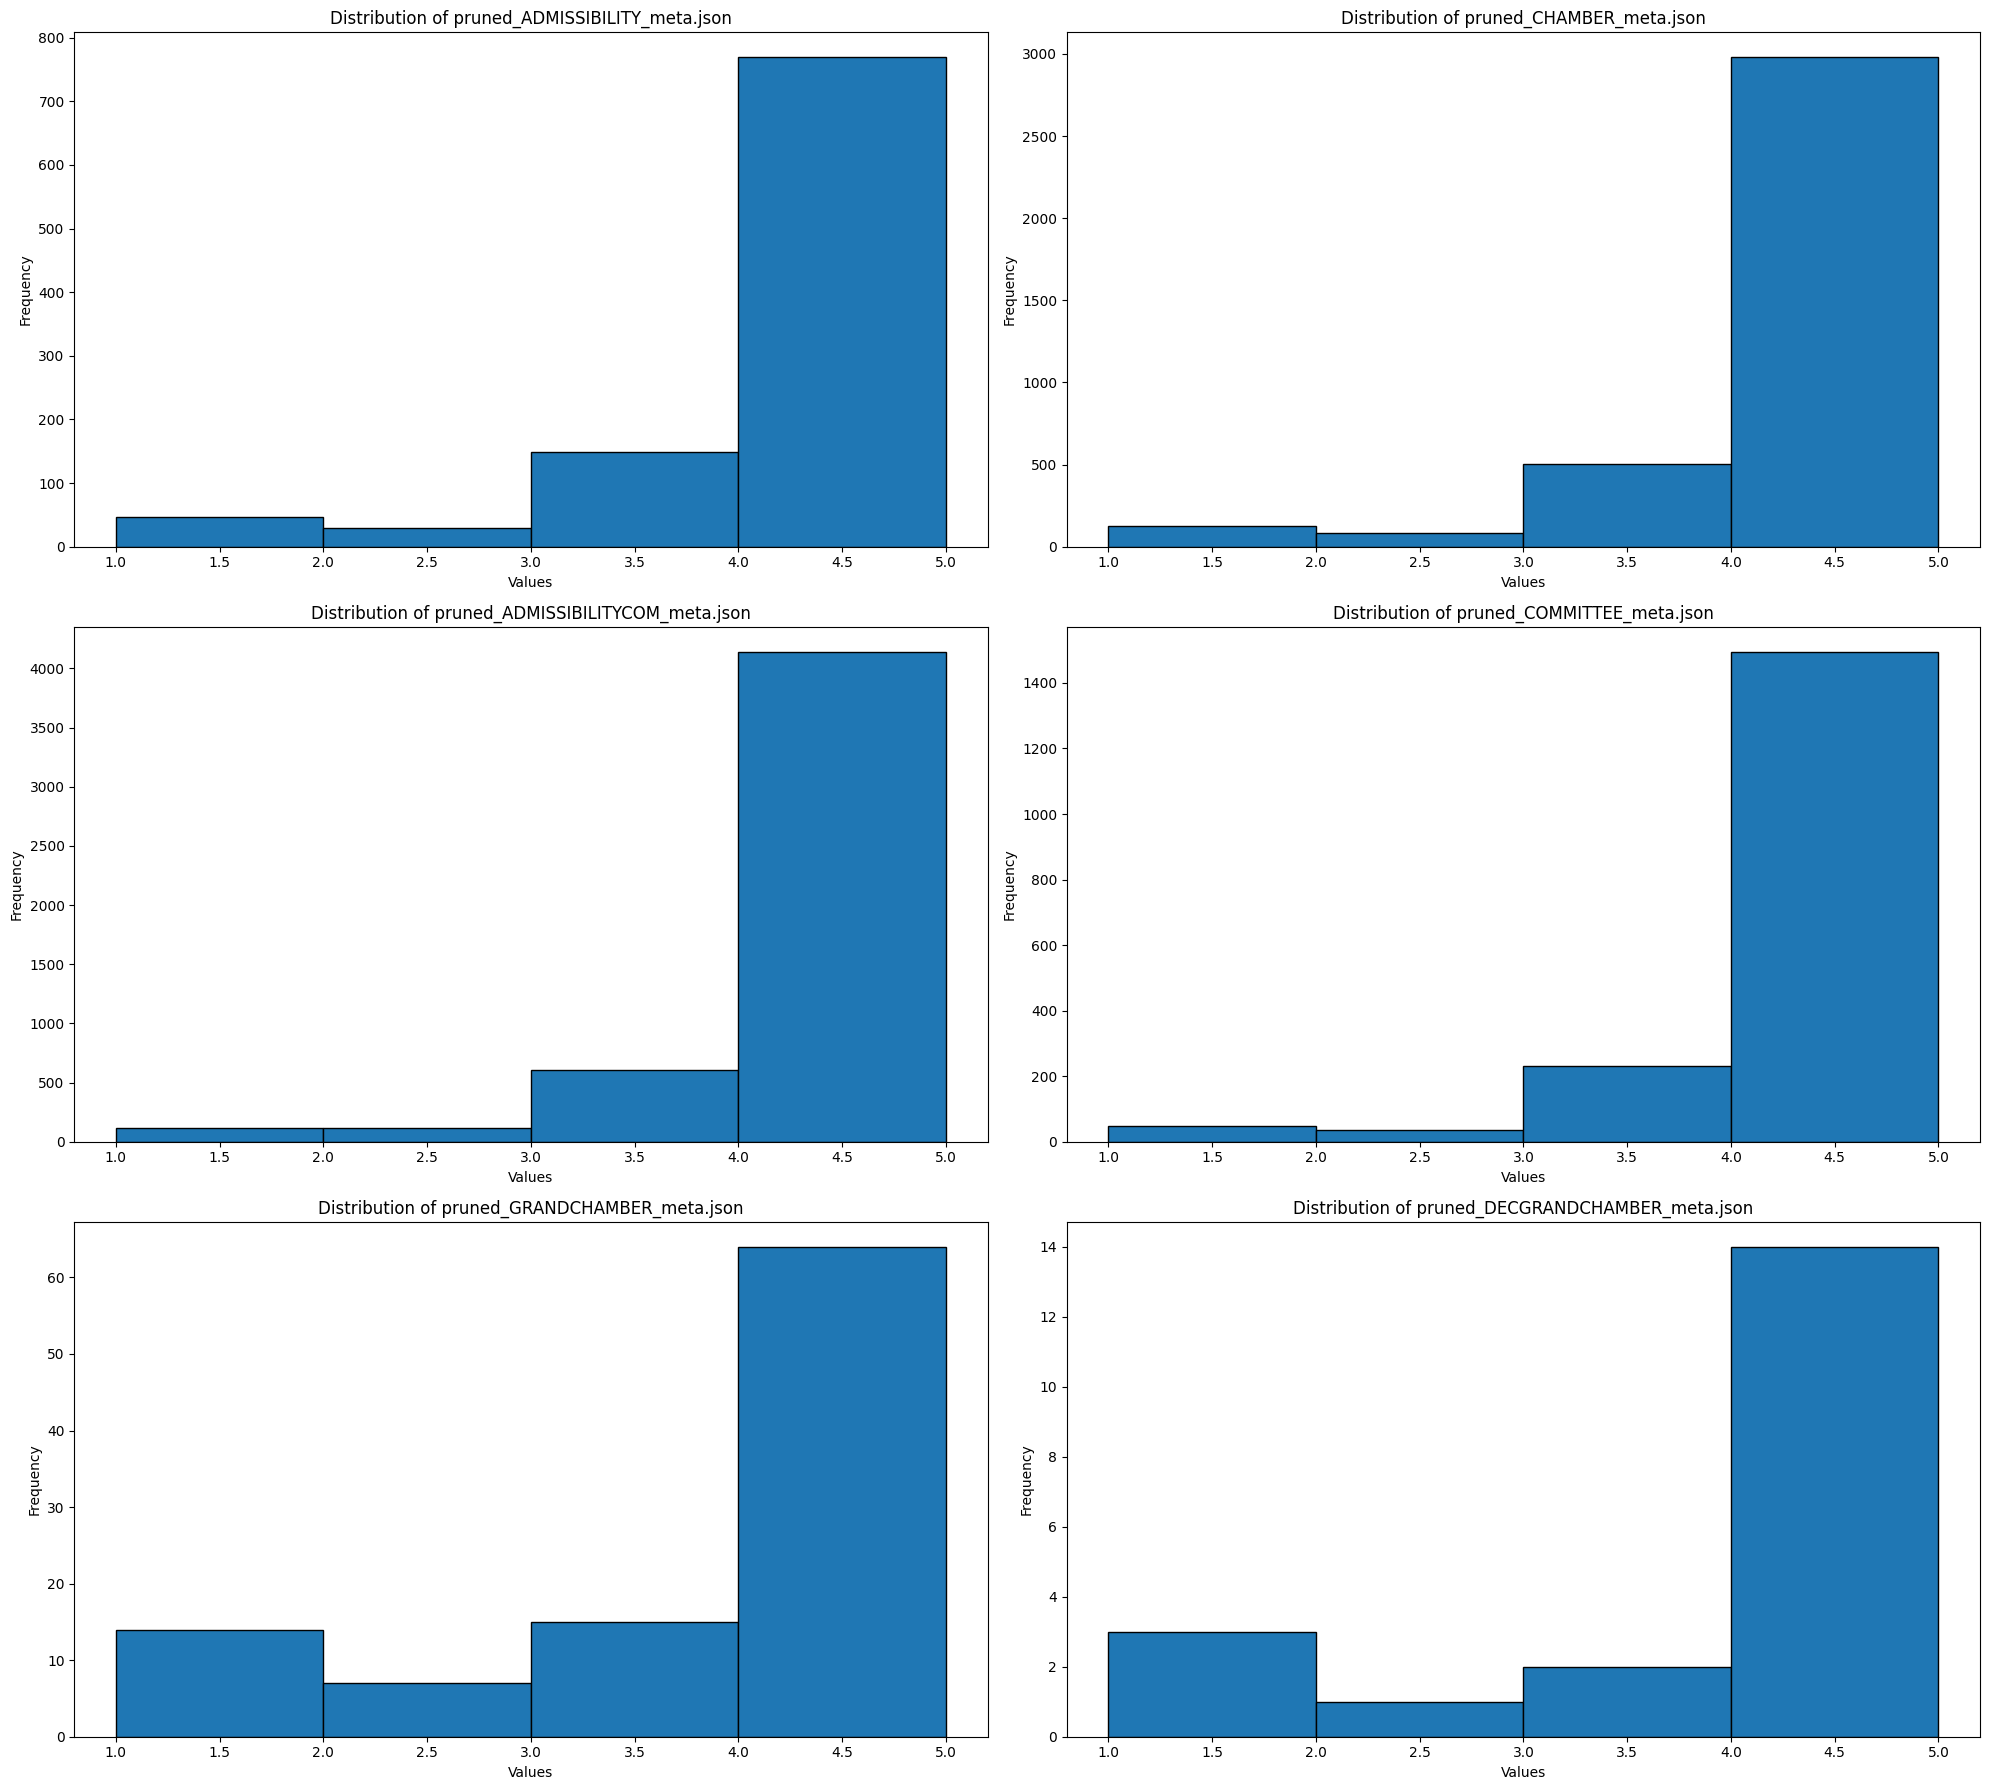

In [15]:
import matplotlib.pyplot as plt

# Number of categories
num_categories = len(category_dict)

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 3 * num_categories))

axes = axes.flatten()

# Plot each distribution in a separate subplot
for ax, (category, values) in zip(axes, category_dict.items()):
    all_ints = [val for sublist in values for val in sublist]
    ax.hist(all_ints, bins=range(min(all_ints), max(all_ints) + 2), edgecolor='black')
    ax.set_xlabel('Values')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {category}')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Flatten the list of integers from the dictionary values
all_ints = [val for sublist in new_results.values() for val in sublist]
#Plot the distribution
plt.hist(all_ints, bins=range(min(all_ints), max(all_ints) + 2), edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of W/ Relevance Scores')
plt.show()

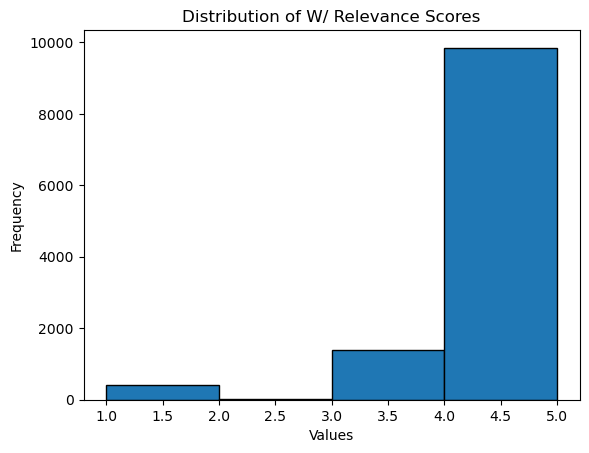

In [71]:
import matplotlib.pyplot as plt

# Flatten the list of integers from the dictionary values
all_ints = [val for sublist in new_results.values() for val in sublist]
#Plot the distribution
plt.hist(all_ints, bins=range(min(all_ints), max(all_ints) + 2), edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of W/ Relevance Scores')
plt.show()

In [16]:
def find_file_no(similar_cases, outcome_cases):

    file_numbers = {}
            
    #find fileNo and importance for most recent appNo case
    for i in similar_cases:
        cases = outcome_cases[outcome_cases['appno'].str.contains(i)]
        cases.sort_values(by='date',ascending=True,inplace=True)

        importance = cases.iloc[-1]['importance']
        fileNo = cases.iloc[-1]['File']

        file_numbers[fileNo] = importance

    return file_numbers

In [17]:
# Load the data
test_data = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/test.pkl')
test_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/comm_test_summaries.pkl')

assert len(test_data) == len(test_summaries)

# Load the outcome cases
outcome_cases = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/outcome_cases.pkl')
outcome_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/outcome_summaries.pkl')

assert len(outcome_cases) == len(outcome_summaries)


In [18]:
results_gold = {}

for i in range(len(test_data)):

    similar_cases = test_data.iloc[i]['extracted_apps']

    file_numbers = find_file_no(similar_cases=similar_cases, outcome_cases=outcome_cases)

    results_gold[test_data.iloc[i]['Filename']] = file_numbers

/tmp/ipykernel_82079/336010001.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cases.sort_values(by='date',ascending=True,inplace=True)


In [19]:
import pickle

with open('results_gold.pkl', 'wb') as f:
    pickle.dump(results_gold, f)

In [20]:
new_results_2 = {}

for key, inner_dict in results_gold.items():
    new_values = []
    for inner_key, inner_value in inner_dict.items():
        new_values.append(inner_value)
    new_results_2[key] = new_values

In [21]:
category_list = list(metadata['source_file'].unique())

category_dict = {i:[] for i in category_list}

for key, value in new_results_2.items():
    key = metadata[metadata['Filename'] == key]['source_file']

    if key.iloc[0] in category_dict:
        category_dict[key.iloc[0]].append(value)


In [22]:
new_results_2

{'001-203620': [3, 3, 4, 4, 3, 3, 3],
 '001-119280': [1, 4, 4, 3, 4, 4, 3, 4, 4],
 '001-218520': [1, 4, 1, 2, 3],
 '001-201485': [1, 1, 4, 3, 1],
 '001-114722': [3, 1, 1, 1, 2, 1, 3, 4, 1, 4, 1, 1, 1, 3],
 '001-114730': [1, 4, 1, 1, 4, 4, 4, 1, 4],
 '001-174130': [3, 4, 1, 4, 4, 2],
 '001-146080': [1, 1, 4, 1, 1, 3, 1, 1, 1, 1],
 '001-144991': [4, 4, 4, 2],
 '001-123752': [4, 4, 4, 4, 4, 4, 3],
 '001-160933': [4, 1, 4, 4, 1, 4, 1, 4, 2, 4, 1],
 '001-179960': [1, 2, 4, 1, 1, 4, 4, 4],
 '001-146918': [3, 1, 2, 1],
 '001-120365': [4, 3, 4, 1, 1, 2, 3, 4, 3, 1, 3],
 '001-118380': [3, 4, 3, 1],
 '001-176232': [3, 2, 3, 3, 3],
 '001-122556': [3, 3, 3, 3, 4, 3, 3, 4],
 '001-120361': [1, 1, 1, 3, 3, 1, 2, 1, 3, 1, 3, 1, 1, 2, 3, 4],
 '001-109459': [1, 4, 1, 4, 3, 1, 4, 3, 3],
 '001-173997': [3, 1, 4, 4, 4, 1, 4, 1, 4],
 '001-189467': [4, 4, 1, 3, 1, 1, 1, 2, 1, 2, 1, 1, 1, 3, 1, 1, 4, 1, 3, 1],
 '001-113152': [1, 1],
 '001-158424': [4, 3, 1, 3, 1, 1, 3, 1, 3, 2, 4, 3, 2, 4, 3, 4, 1, 1],
 '001-

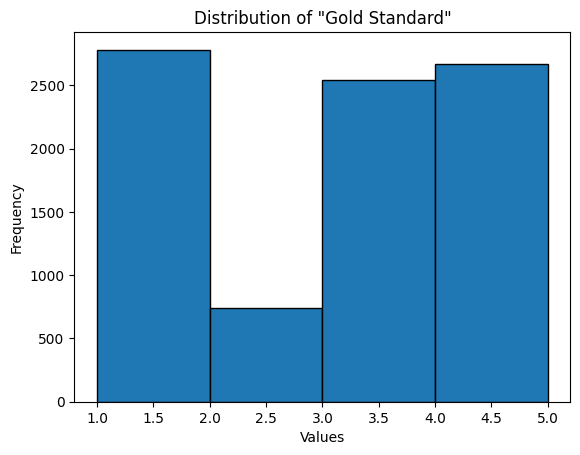

In [24]:
import matplotlib.pyplot as plt
# Flatten the list of integers from the dictionary values
all_ints_gold = [val for sublist in new_results_2.values() for val in sublist]
#Plot the distribution
plt.hist(all_ints_gold, bins=range(min(all_ints_gold), max(all_ints_gold) + 2), edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Distribution of "Gold Standard"')
plt.show()

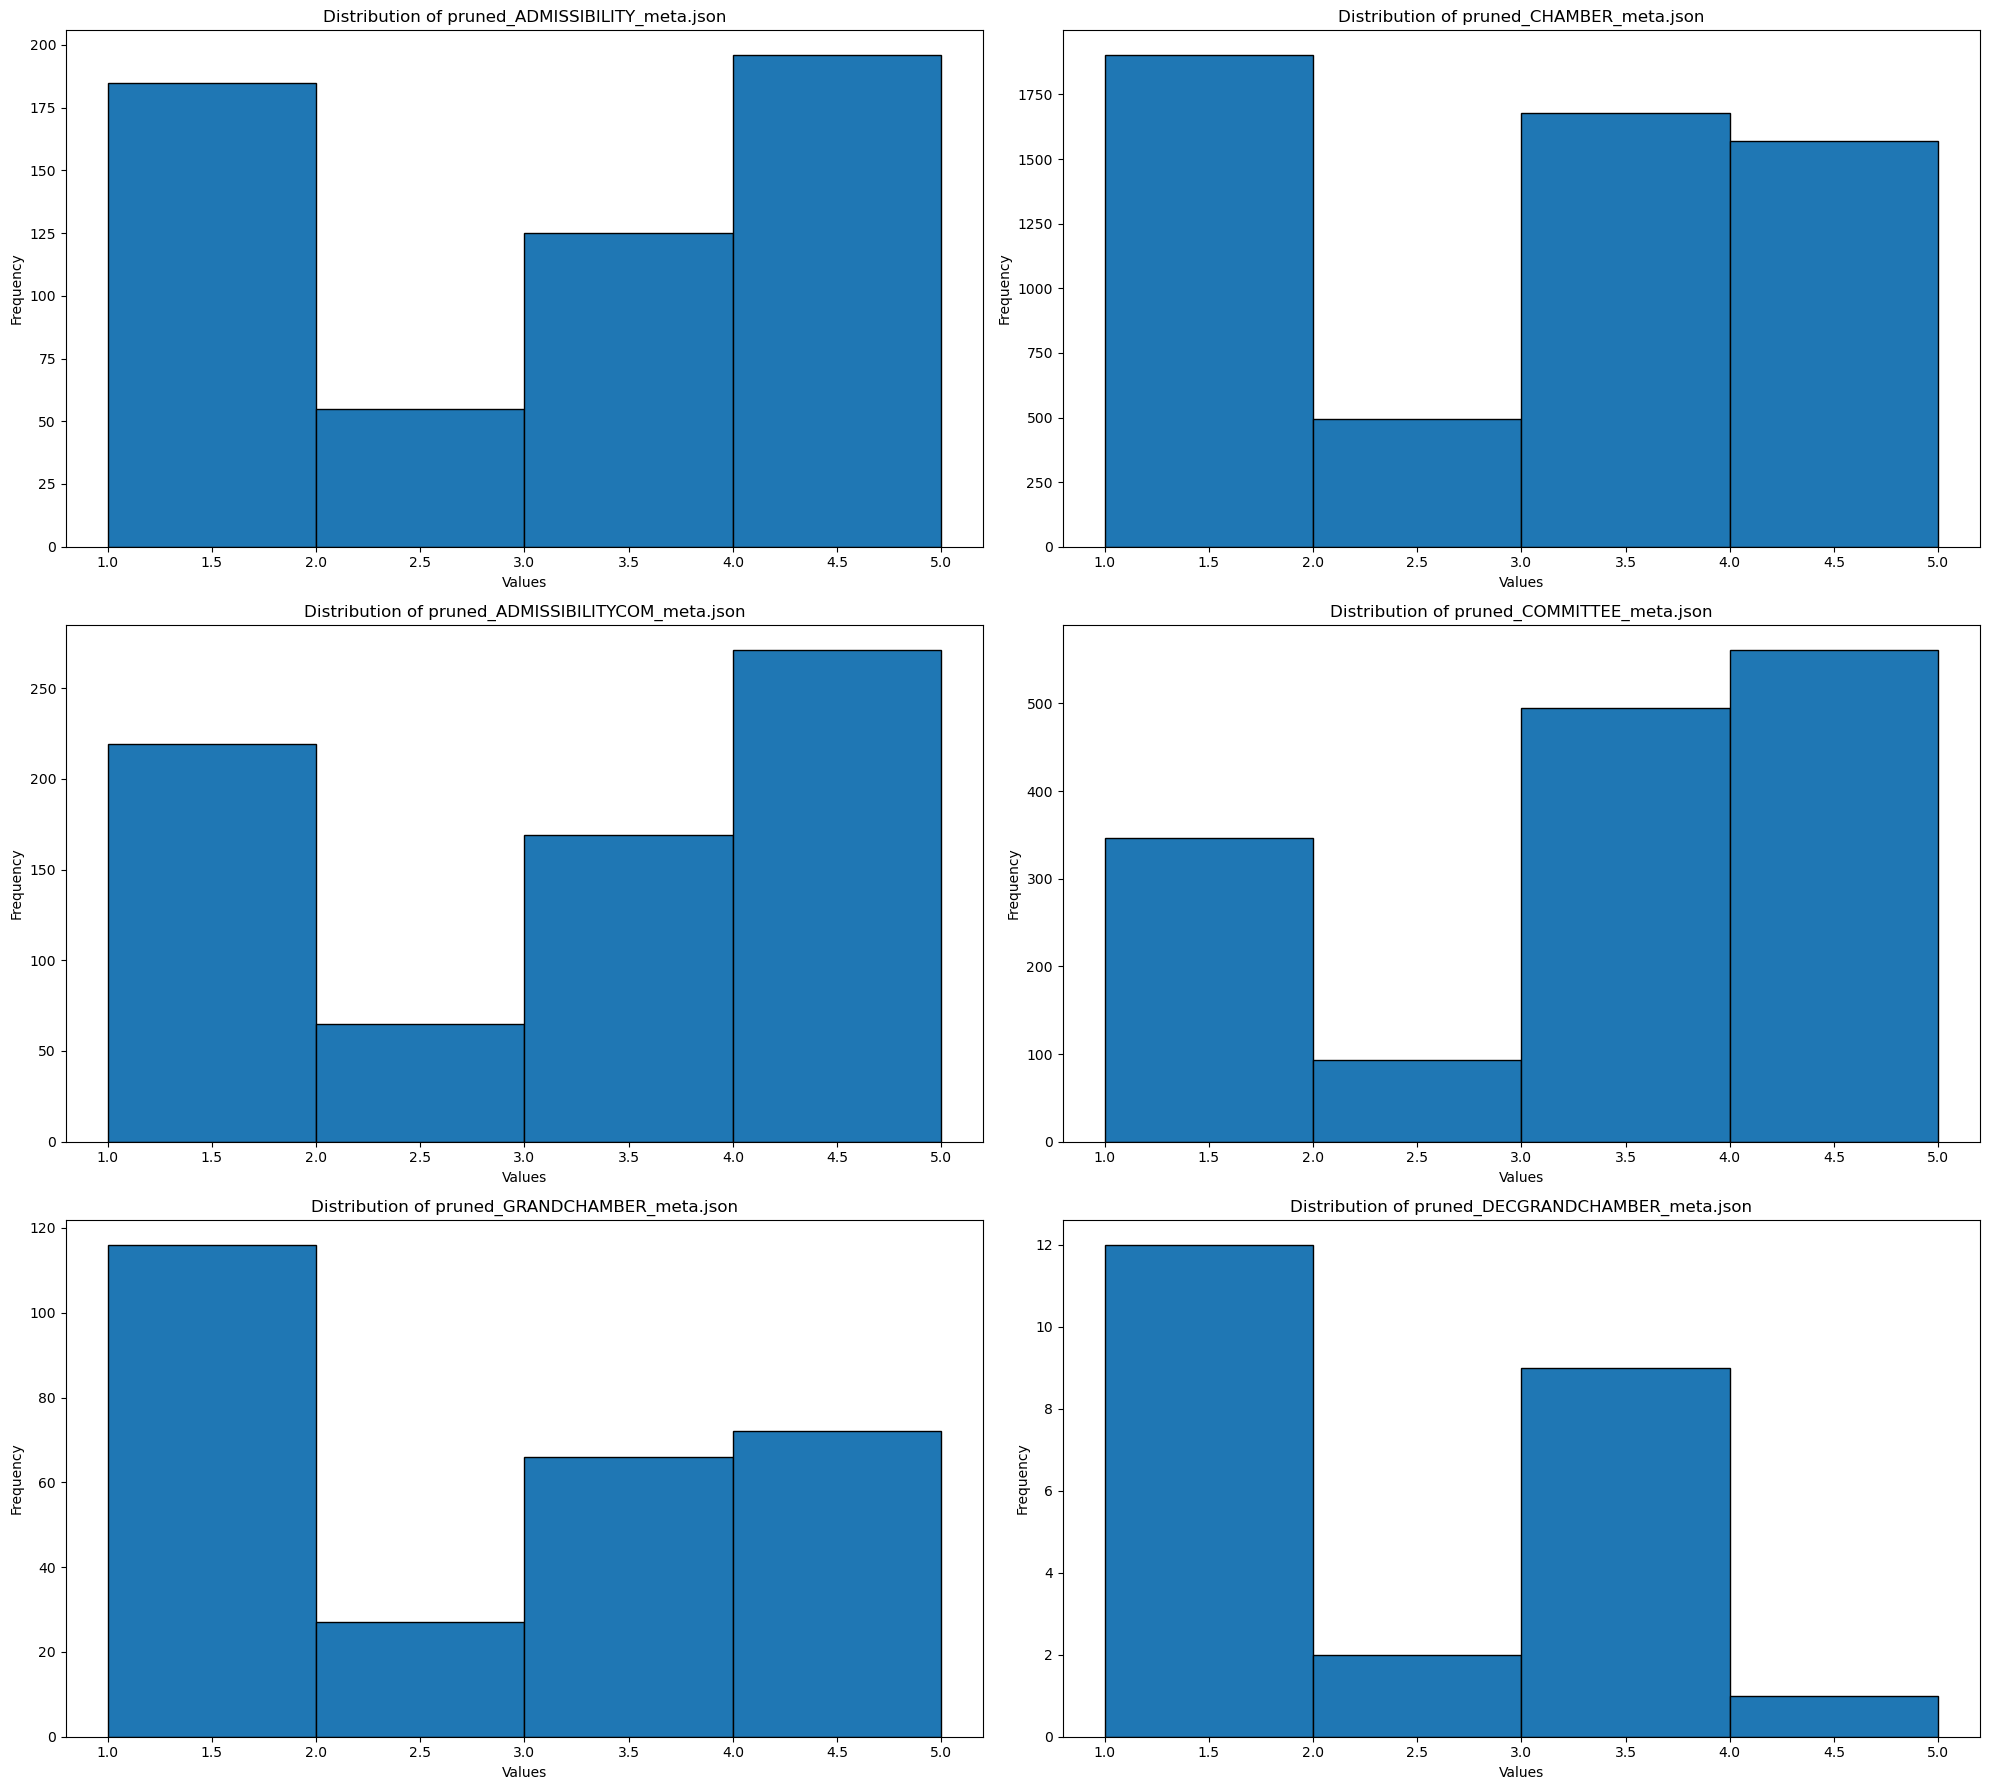

In [86]:
import matplotlib.pyplot as plt

# Number of categories
num_categories = len(category_dict)

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 3 * num_categories))

axes = axes.flatten()

# Plot each distribution in a separate subplot
for ax, (category, values) in zip(axes, category_dict.items()):
    all_ints = [val for sublist in values for val in sublist]
    ax.hist(all_ints, bins=range(min(all_ints), max(all_ints) + 2), edgecolor='black')
    ax.set_xlabel('Values')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {category}')

# Adjust layout
plt.tight_layout()
plt.show()

In [23]:
from collections import Counter

#will select the first seen element in case of ties.

def Most_Common(lst):
    data = Counter(lst)
    return data.most_common(1)[0][0]

In [24]:
filepath = '/users/sgdbareh/volatile/ECHR_Importance/PREDICTION/batches/TEST_SEMANTIC_NO_RELEVANCE'

In [25]:
results_overall = {}

for file in os.listdir(f'{filepath}'):

    results_temp = {}
        
    if file.endswith('_FILENO.pkl'):

        print(file)

        data = pd.read_pickle(f'{filepath}/{file}')
        
        for key, value in data.items():
            importances = [val for val in value.values()]

            #if no relevant cases can be found at all - set importance to 1
            if len(importances) == 0:
                importance = 1
            else:
                importance = Most_Common(importances)
            
            results_temp[key] = importance


        results_overall[file] = results_temp


final_examples_3_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
final_examples_3_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_3_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_3_BM25_EXAMPLE_DICT_FILENO.pkl
final_examples_5_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
final_examples_5_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_5_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_5_BM25_EXAMPLE_DICT_FILENO.pkl
final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
final_examples_10_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_10_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
final_examples_10_BM25_EXAMPLE_DICT_FILENO.pkl


In [26]:
from results import combine_results, process_results, confusion_matrix, data_process, process_as_binary, score_results, score_results_MAE, score_results_spearman


In [27]:
results_temp = {}

for key, importances in new_results_2.items():

    #if no relevant cases can be found at all - set importance to 1
    if len(importances) == 0:
        importance = 4
    else:
        importance = Most_Common(importances)
    
    results_temp[key] = importance

results_overall['Gold'] = results_temp


final_examples_3_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
MAE: 0.21232876712328766
Spearman: SignificanceResult(statistic=0.045828326118132555, pvalue=0.11749500126157439)


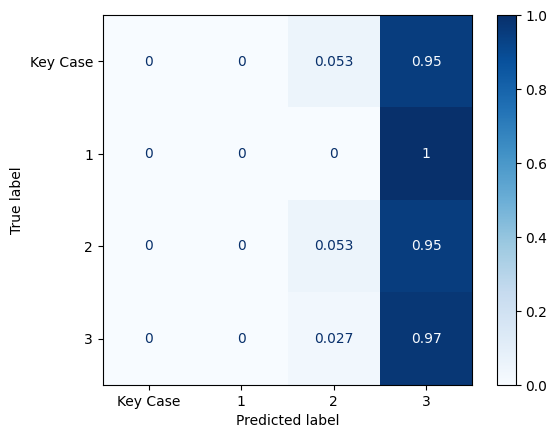



final_examples_3_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.3690068493150685
Spearman: SignificanceResult(statistic=0.06750091752681446, pvalue=0.02105069824651285)


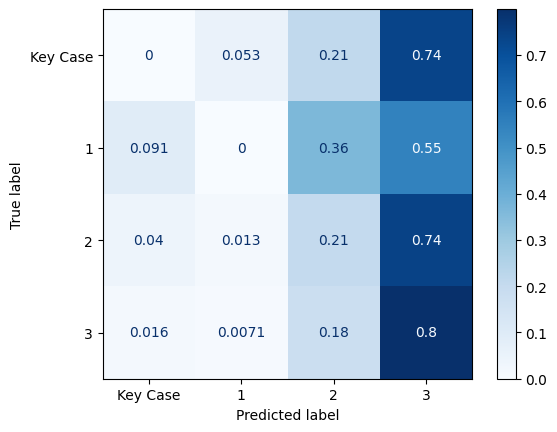



final_examples_3_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.3202054794520548
Spearman: SignificanceResult(statistic=-0.0034987800654696496, pvalue=0.9049214701401745)


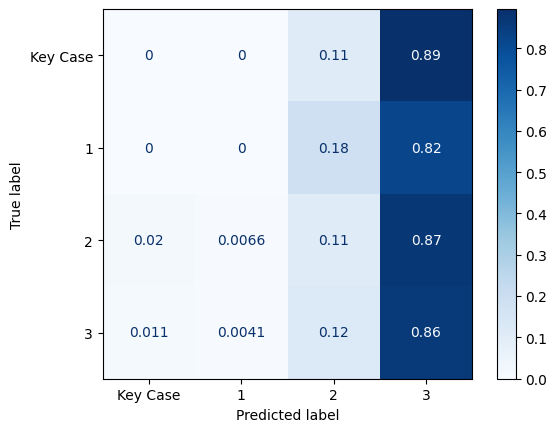



final_examples_3_BM25_EXAMPLE_DICT_FILENO.pkl
MAE: 0.5590753424657534
Spearman: SignificanceResult(statistic=0.04344657397754177, pvalue=0.13782441014909397)


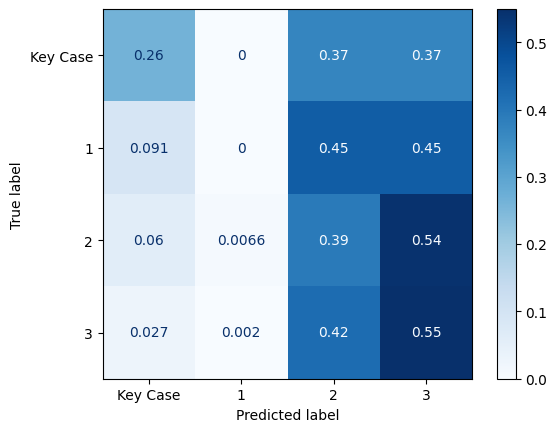



final_examples_5_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
MAE: 0.199486301369863
Spearman: SignificanceResult(statistic=0.08585915392238151, pvalue=0.0033182546106527147)


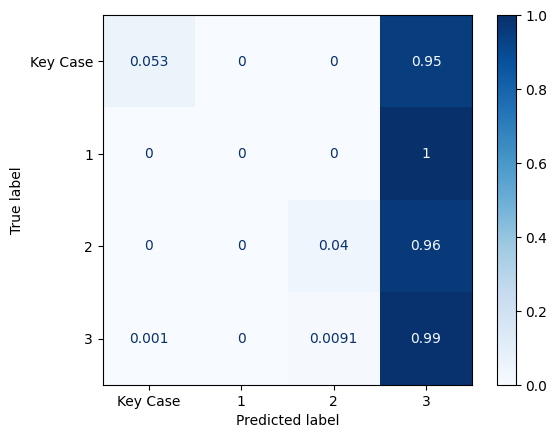



final_examples_5_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.2568493150684932
Spearman: SignificanceResult(statistic=0.014651551148246228, pvalue=0.616918536233669)


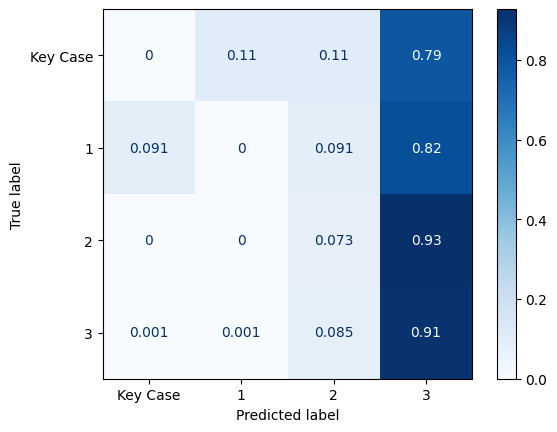



final_examples_5_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.2303082191780822
Spearman: SignificanceResult(statistic=0.03708161473552415, pvalue=0.2053769182524264)


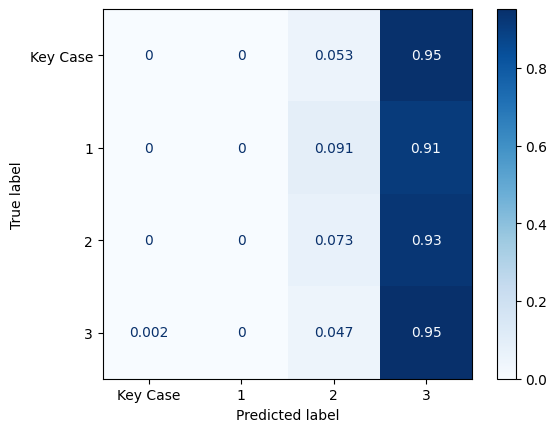



final_examples_5_BM25_EXAMPLE_DICT_FILENO.pkl
MAE: 0.4708904109589041
Spearman: SignificanceResult(statistic=0.0853874057809751, pvalue=0.0034956938045702535)


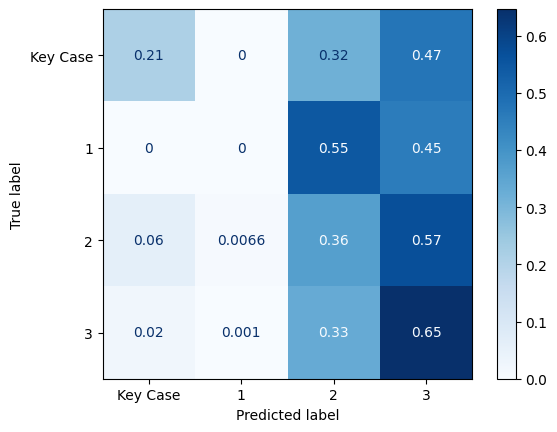



final_examples_10_OPENAI-2048-COSINE_EXAMPLE_DICT_FILENO.pkl
MAE: 0.19777397260273974
Spearman: SignificanceResult(statistic=0.031479133566340065, pvalue=0.28239899098682664)


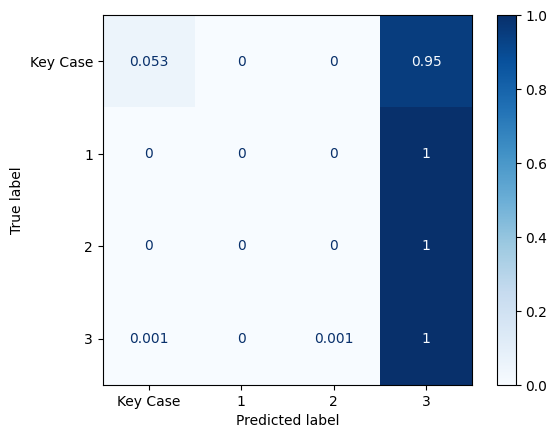



final_examples_10_LBERT-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.21147260273972604
Spearman: SignificanceResult(statistic=0.04856886896165986, pvalue=0.09709720251961186)


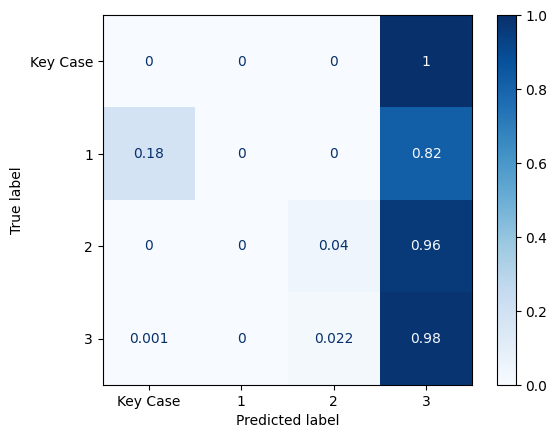



final_examples_10_OPENAI-512-MMR_EXAMPLE_DICT_FILENO.pkl
MAE: 0.19777397260273974
Spearman: SignificanceResult(statistic=0.07201767644951049, pvalue=0.013822670023804317)


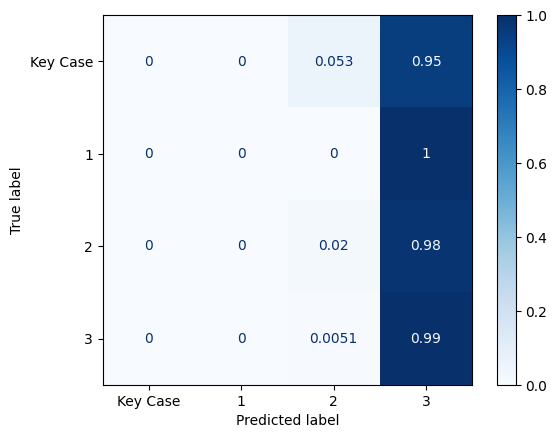



final_examples_10_BM25_EXAMPLE_DICT_FILENO.pkl
MAE: 0.5034246575342466
Spearman: SignificanceResult(statistic=0.003885395369635966, pvalue=0.8944736269097429)


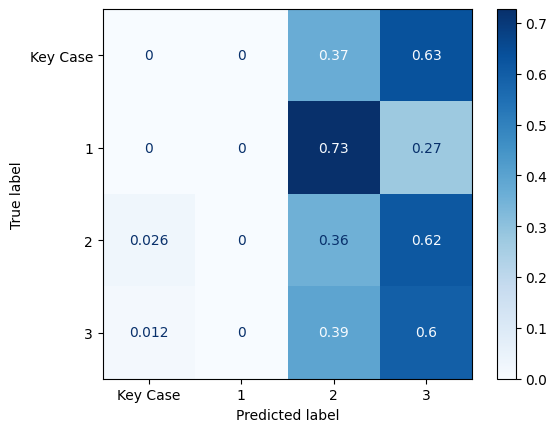



Gold
MAE: 0.8416095890410958
Spearman: SignificanceResult(statistic=0.317087108225769, pvalue=1.082139735005417e-28)


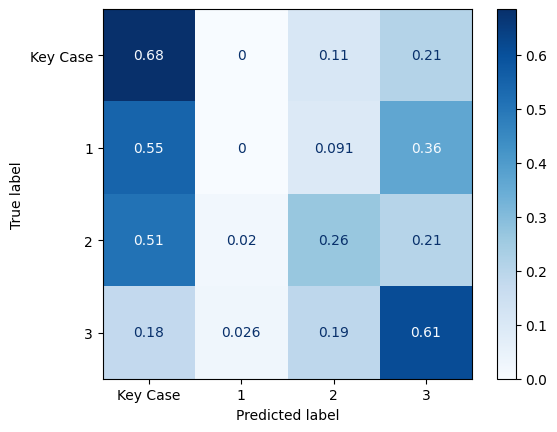

In [28]:

for key, value in results_overall.items():
    print(key)
    df = pd.DataFrame(value.items(), columns=['Filename','Importance'])
    df = pd.merge(test_data,df,on='Filename')
    y_true = df['importance'] #real_court
    y_pred = df['Importance'] #Court

    try:
        y_pred = y_pred.astype('int64')
    except:
        print('can\'t convert to int64')    

    score_results_MAE(y_true,y_pred)
    score_results_spearman(y_true,y_pred)
    confusion_matrix(y_true,y_pred)
    print('\n')


In [149]:
train = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/VectorDB/train.pkl')


In [152]:
train.iloc[50]['Subject Matter']

'The applicant, Mr Yuriy Vladimirovich Budanov, is a Russian national who was born in 1972 and lived until his arrest in the town of Morshansk, Tambov Region.The facts of the case, as submitted by the applicant, may be summarised as follows.A. Criminal proceedings against the applicantOn 25 October 2004 the applicant was arrested and placed in temporary detention facility no. IZ-68/2 in Morshansk.On 1 February 2005 the Morshansk District Court found him guilty of murder and sentenced him to ten years of imprisonment. With the judgment becoming final on 10 March 2005, the applicant was sent to serve his sentence in correctional colony no. 5B. The applicant’s state of healthAs follows from evidence presented by the applicant, in 2000 he was admitted for inpatient treatment to the neurological department of the Morshansk Town hospital following his complaints of frequent seizures and loss of consciousness. He was diagnosed with episyndrome against the background of vascular malformation i